# Batch gradient descent

In [1]:
from sklearn.datasets import load_diabetes
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
import time

In [2]:
X,y = load_diabetes(return_X_y=True)

In [3]:
print(X.shape)
print(y.shape)

(442, 10)
(442,)


In [4]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [5]:
model=LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [6]:
model.coef_



array([  -9.15865318, -205.45432163,  516.69374454,  340.61999905,
       -895.5520019 ,  561.22067904,  153.89310954,  126.73139688,
        861.12700152,   52.42112238])

In [7]:
model.intercept_

np.float64(151.88331005254167)

In [8]:
y_pred=model.predict(X_test)
r2_score(y_test,y_pred)

0.4399338661568968

In [9]:
class GDRegressor:
    def __init__(self, learning_rate=0.01, epochs=100):

        self.coef_ = None
        self.intercept_ = None
        self.lr = learning_rate
        self.epochs = epochs

    def fit(self,X_train,y_train):
            self.intercept_ = 0
            self.coef_ = np.ones(X_train.shape[1])
            print(self.intercept_ , self.coef_)

            for i in range(self.epochs):
                y_hat = np.dot(X_train,self.coef_) + self.intercept_
                # print("shape of y_hat" ,y_hat.shape)
                intercept_der = -2 * np.mean(y_train - y_hat)
                self.intercept_ = self.intercept_ - (self.lr * intercept_der)

                coef_der = -2 *np.dot((y_train-y_hat),X_train)/X_train.shape[0]
                self.coef_ = self.coef_ - (self.lr * coef_der)

    def predict(self,X_test):
            return np.dot(X_test,self.coef_)+self.intercept_






In [10]:
gdr = GDRegressor(epochs=100 , learning_rate=0.7)

In [11]:
start = time.time()
gdr.fit(X_train,y_train)
print("Time taken is ",time.time()-start)


0 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Time taken is  0.00830531120300293


In [12]:
print(gdr.intercept_)
print(gdr.coef_)

151.7495705696168
[  58.22950196   -8.80273108  209.91902523  156.45259902   43.24483786
   21.94791198 -119.11184297  111.02618872  198.44133386  104.55417601]


In [13]:
y_pred = gdr.predict(X_test)


In [14]:
r2_score(y_test,y_pred)

0.3625911725141632

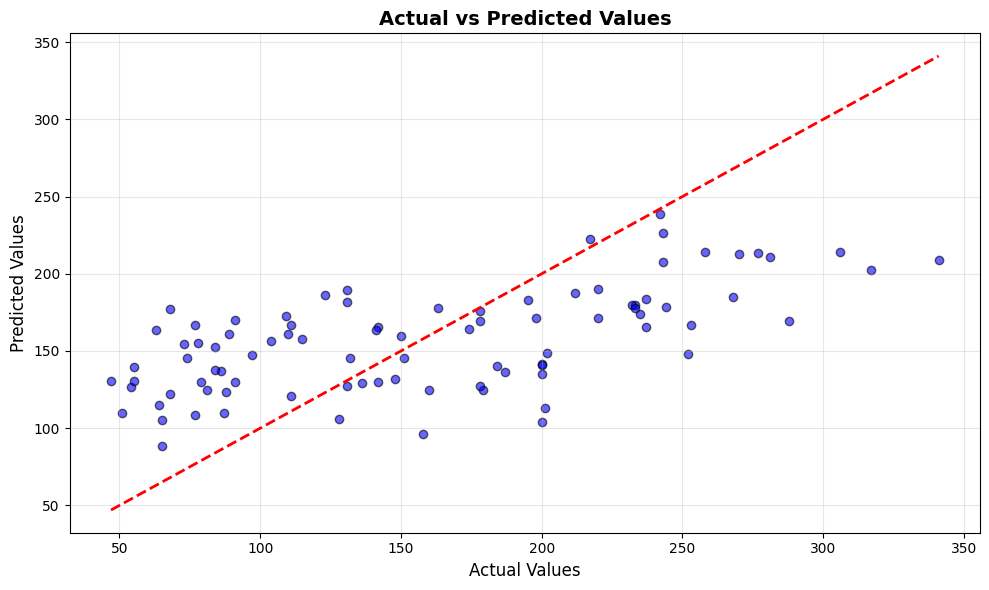

In [15]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='blue', edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Values', fontsize=12)
plt.ylabel('Predicted Values', fontsize=12)
plt.title('Actual vs Predicted Values', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


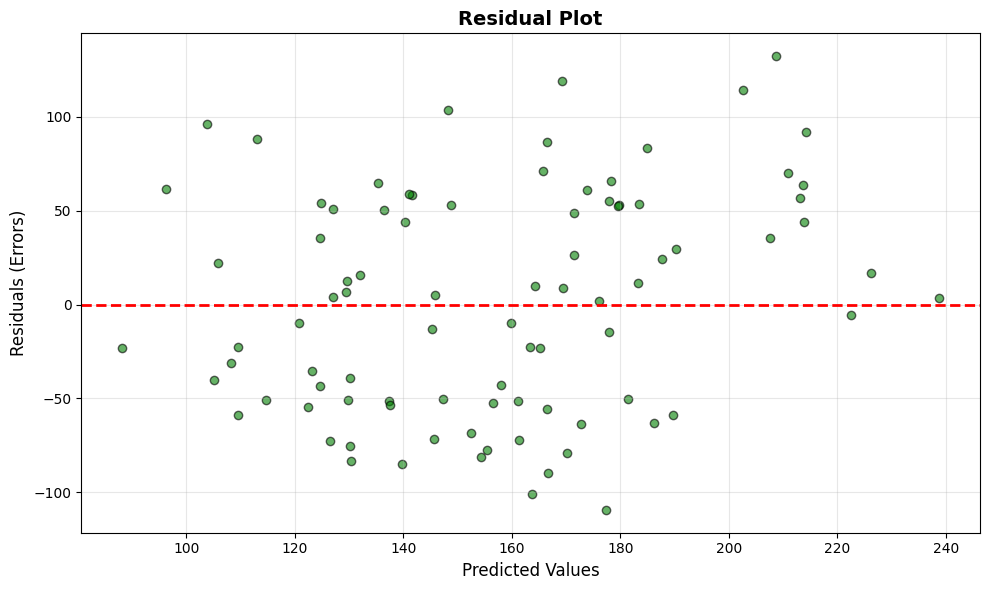

In [16]:
residuals = y_test - y_pred
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.6, color='green', edgecolors='k')
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
plt.xlabel('Predicted Values', fontsize=12)
plt.ylabel('Residuals (Errors)', fontsize=12)
plt.title('Residual Plot', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

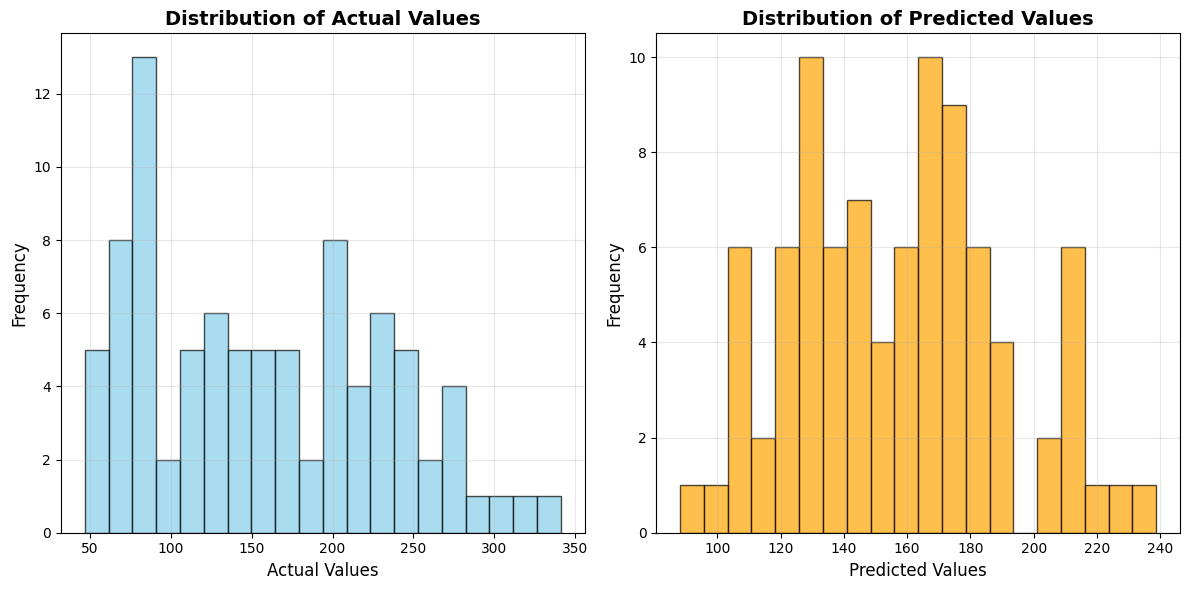

In [17]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.hist(y_test, bins=20, color='skyblue', edgecolor='black', alpha=0.7)
plt.xlabel('Actual Values', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Actual Values', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(y_pred, bins=20, color='orange', edgecolor='black', alpha=0.7)
plt.xlabel('Predicted Values', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Predicted Values', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


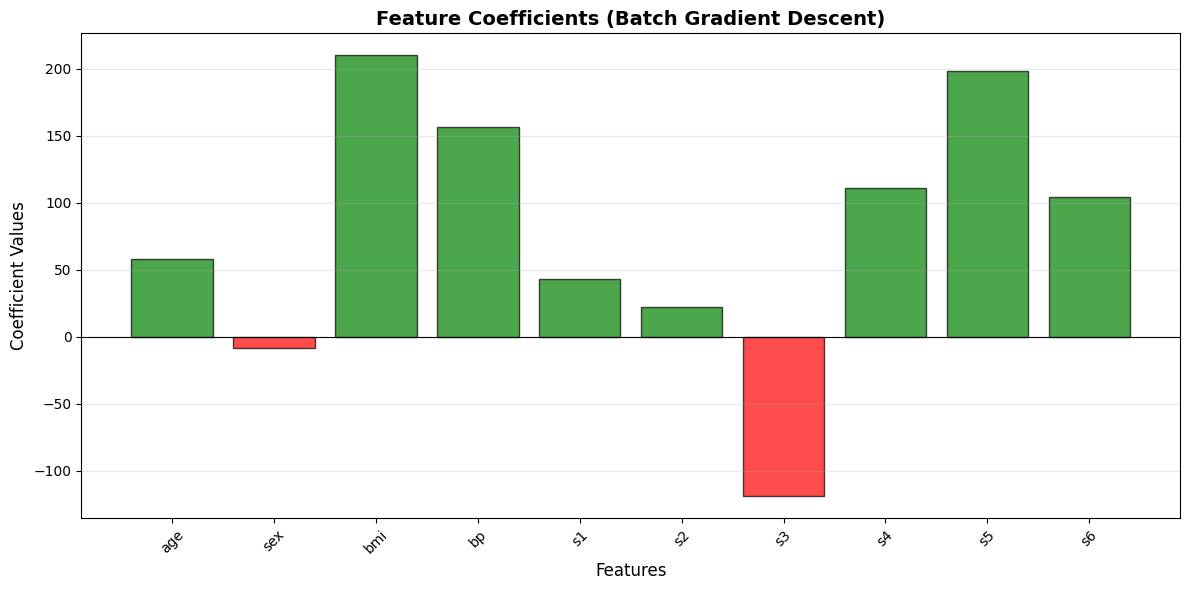

In [18]:
feature_names = ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
plt.figure(figsize=(12, 6))
colors = ['red' if c < 0 else 'green' for c in gdr.coef_]
plt.bar(feature_names, gdr.coef_, color=colors, alpha=0.7, edgecolor='black')
plt.xlabel('Features', fontsize=12)
plt.ylabel('Coefficient Values', fontsize=12)
plt.title('Feature Coefficients (Batch Gradient Descent)', fontsize=14, fontweight='bold')
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

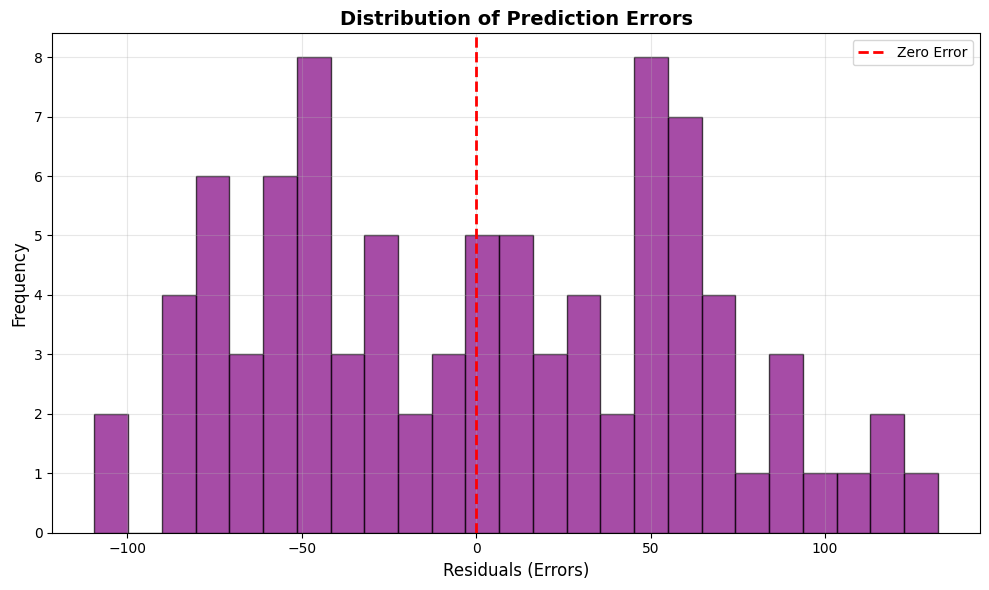

In [19]:
plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=25, color='purple', edgecolor='black', alpha=0.7)
plt.xlabel('Residuals (Errors)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Prediction Errors', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='r', linestyle='--', linewidth=2, label='Zero Error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

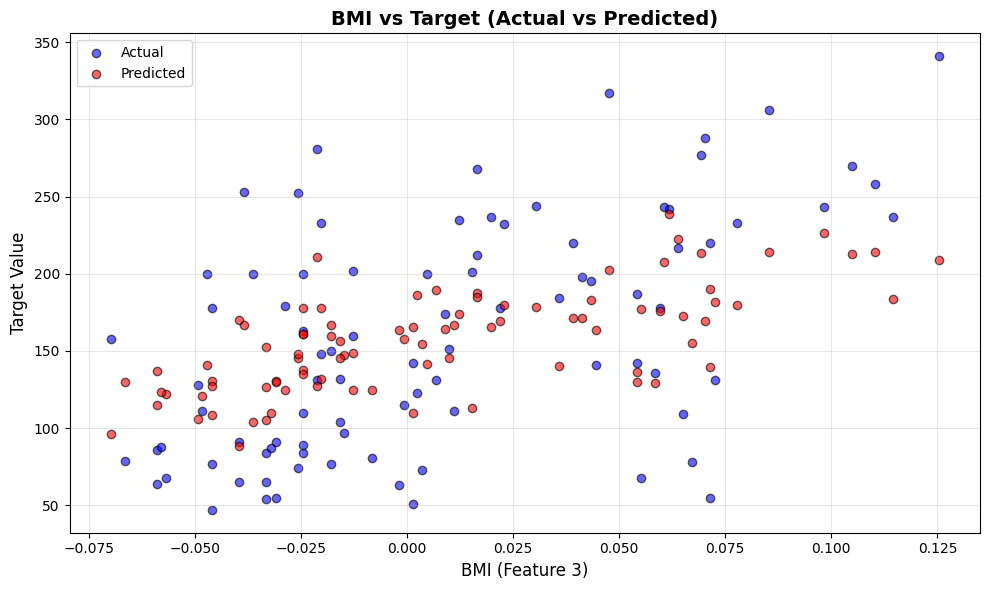

\n📊 All graphs plotted successfully!
R² Score: 0.3626
Intercept: 151.75
Mean Absolute Error: 51.51


In [20]:
plt.figure(figsize=(10, 6))
plt.scatter(X_test[:, 2], y_test, alpha=0.6, color='blue', label='Actual', edgecolors='k')
plt.scatter(X_test[:, 2], y_pred, alpha=0.6, color='red', label='Predicted', edgecolors='k')
plt.xlabel('BMI (Feature 3)', fontsize=12)
plt.ylabel('Target Value', fontsize=12)
plt.title('BMI vs Target (Actual vs Predicted)', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\\n📊 All graphs plotted successfully!")
print(f"R² Score: {r2_score(y_test, y_pred):.4f}")
print(f"Intercept: {gdr.intercept_:.2f}")
print(f"Mean Absolute Error: {np.mean(np.abs(residuals)):.2f}")